In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from torch.utils.data import Dataset,DataLoader

from sklearn.model_selection import train_test_split

In [3]:
pd.set_option('display.max_columns', None)

In [6]:
original_df = pd.read_csv('4.6_dataset_feature_selected.csv')


In [5]:
df = original_df.copy()
df

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,servant_room,luxury_category,parking,building_type
0,sector 39,0.70,1278.0000,2,2,2,1 to 5 year old,0,medium,1,low-rise
1,sohna,0.38,682.3526,2,2,2,1 to 5 year old,0,medium,2,mid-rise
2,sector 71,1.35,1198.0000,2,2,2,10+ year old,0,high,1,mid-rise
3,sector 82,3.40,3240.0000,4,4,2,0 to 1 year old,1,medium,2,low-rise
4,sohna,0.95,1065.0000,2,2,2,0 to 1 year old,0,low,1,low-rise
...,...,...,...,...,...,...,...,...,...,...,...
5584,sohna,0.88,1313.5000,4,4,2,5 to 10 year old,0,medium,2,mid-rise
5585,sector 99,3.75,3500.0000,4,4,3+,1 to 5 year old,1,high,2,mid-rise
5586,sector 92,1.45,1628.0000,3,4,3+,1 to 5 year old,1,medium,1,mid-rise
5587,sector 65,3.85,2916.6800,3,3,2,0 to 1 year old,0,medium,0,high-rise


In [7]:
X = df.drop(columns=['price'])
Y = df['price']

<Axes: ylabel='Frequency'>

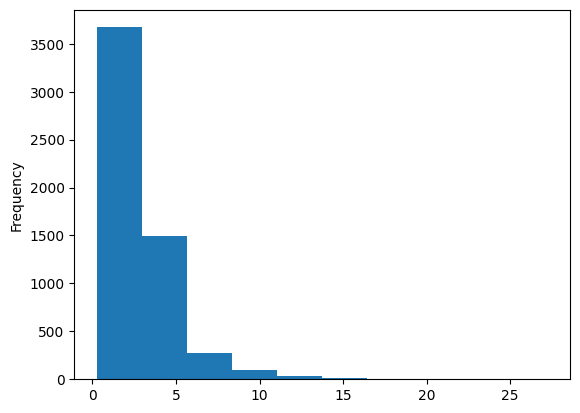

In [9]:
Y.plot(kind='hist')

<Axes: >

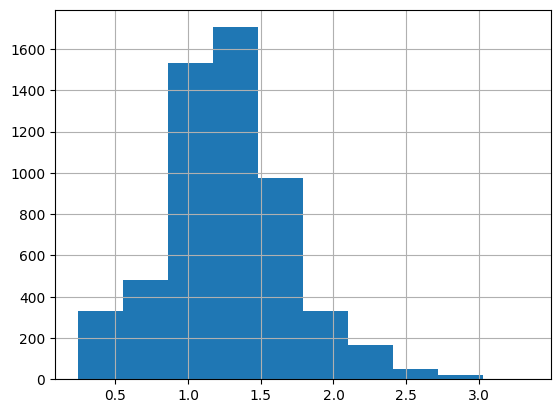

In [13]:
np.log1p(Y).hist()

In [14]:
y_transformed = np.log1p(Y)

## Applying column transformations

In [15]:
X.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sector           5589 non-null   object 
 1   super_area       5589 non-null   float64
 2   bedrooms         5589 non-null   int64  
 3   bathroom         5589 non-null   int64  
 4   balcony          5589 non-null   object 
 5   age_possession   5589 non-null   object 
 6   servant_room     5589 non-null   int64  
 7   luxury_category  5589 non-null   object 
 8   parking          5589 non-null   int64  
 9   building_type    5589 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 436.8+ KB


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder

ordinal_order = [
	['0', '1', '2', '3', '3+'],
	['under construction','0 to 1 year old','1 to 5 year old', '5 to 10 year old','10+ year old' ],
    ['low','medium','high']
]

ordinal_cols = ['balcony','age_possession','luxury_category']

column_transformer = ColumnTransformer(
	transformers=[
	('scaling',StandardScaler(),['super_area','bedrooms','bathroom','servant_room','parking']),
	('ordinal_cols',OrdinalEncoder(categories=ordinal_order),ordinal_cols),
	('onehot',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False),['sector','building_type'])
	],
	remainder='passthrough'
)

### Building data pipeline

In [55]:
#data pipeline
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

column_transformer.fit(x_train,y_train) #y_train gets ignored automatically


,transformers,"[('scaling', ...), ('ordinal_cols', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [56]:
x_train_transformed = column_transformer.transform(x_train)
x_test_transformed = column_transformer.transform(x_test)

/Users/rahulvashisth/Downloads/Telegram Download/Code Practice/myenv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [57]:
#building custom dataset class

class CustomDataset(Dataset):
	
    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype = torch.float32)
        self.labels = torch.tensor(labels,dtype = torch.float32)

    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [58]:
#creating train and test dataset
train_dataset = CustomDataset(x_train_transformed,y_train.values)
test_dataset = CustomDataset(x_test_transformed,y_test.values)

In [59]:
#create train and test dataloader
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_dataloader = DataLoader(test_dataset,shuffle=False)

In [60]:
len(train_loader)

140

### Building Model

In [106]:
#defining the ANN network

import torch.nn as nn

class MyNN(nn.Module):
	
    def __init__(self,num_features):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features=num_features,out_features=128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(in_features=128,out_features=512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(in_features=512,out_features=512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(in_features=512,out_features=512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(in_features=512,out_features=512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(in_features=512,out_features=512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(in_features=512,out_features=256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(in_features=256,out_features=128),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(in_features=128,out_features=1)
        )
    
    def forward(self,features):
        out = self.network(features)
        return out
    
model = MyNN(x_train_transformed.shape[1])


learning_rate = 1e-2
epochs = 200
loss_function = nn.L1Loss()
optimizer = torch.optim.RMSprop(params=model.parameters(),lr=learning_rate)

In [107]:
#training loop

for epoch in range(epochs):
	
    total_epoch_loss = 0

    for batch_features,batch_labels in train_loader:

        #forward pass
        y_pred = model(batch_features)

        #calc loss for current epoch
        loss = loss_function(y_pred,batch_labels)

        #clear gradients
        optimizer.zero_grad()

        #backward pass
        loss.backward()

        #update gradients
        optimizer.step()

        #calc total loss for current epoch
        total_epoch_loss = total_epoch_loss + loss.item()
    
    #calc average for current epoch
    avg_epoch_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch : {epoch} , Loss : {avg_epoch_loss}")

/Users/rahulvashisth/Downloads/Telegram Download/Code Practice/myenv/lib/python3.12/site-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/Users/rahulvashisth/Downloads/Telegram Download/Code Practice/myenv/lib/python3.12/site-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([23])) that is different to the input size (torch.Size([23, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch : 0 , Loss : 620800.2627577275
Epoch : 1 , Loss : 1.3441497496196202
Epoch : 2 , Loss : 1.3259825429746084
Epoch : 3 , Loss : 1.3116107881069183
Epoch : 4 , Loss : 1.3220215014048986
Epoch : 5 , Loss : 1.3105072396142141
Epoch : 6 , Loss : 1.3134116560220719
Epoch : 7 , Loss : 1.310571238398552
Epoch : 8 , Loss : 1.3397288858890533
Epoch : 9 , Loss : 1.3101175231592996
Epoch : 10 , Loss : 1.333282800231661
Epoch : 11 , Loss : 1.3439636400767736
Epoch : 12 , Loss : 1.3067244955471584
Epoch : 13 , Loss : 1.308658517258508
Epoch : 14 , Loss : 1.3072023340633938
Epoch : 15 , Loss : 1.306147262454033
Epoch : 16 , Loss : 1.309011921286583
Epoch : 17 , Loss : 1.309377835052354
Epoch : 18 , Loss : 1.308805211527007
Epoch : 19 , Loss : 1.3084975800343923
Epoch : 20 , Loss : 1.3089850229876383
Epoch : 21 , Loss : 1.3090195830379214
Epoch : 22 , Loss : 1.3093347328049796
Epoch : 23 , Loss : 1.3149137837546212
Epoch : 24 , Loss : 1.3118284412792751
Epoch : 25 , Loss : 1.3116617449692318
Epoc